# Red Neuronal para el cálculo de los parámetros de 3 estados del heliceno.
Predicción de 6 parámetros espectrales (l1, R_1, l_{min}, R_{min}, l_{max}, R_{max}) 
con loss function MSE parámetros de manera que el aprendizaje minimice la pérdida en la predicción de las intensidades y longitudes de onda de los 3 estados excitados que estudiamos del heliceno.

## 1. Imports y Configuración global del modelo

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

In [2]:
from dataclasses import dataclass

@dataclass
class Config:
    # Rutas de datos
    path_params: str     = '../Bases de datos/DatasetDefinitivo_2310indep.csv'
    path_env:    str     = '../Bases de datos/Dataset_envolventes.csv'

    # Arquitectura
    input_dim:   int     = 16
    hidden1:     int     = 128
    hidden2:     int     = 64
    hidden3:     int     = 32
    output_dim:  int     = 6

    # Entrenamiento
    lr:          float   = 1e-4
    batch_size:  int     = 16
    epochs:      int     = 300
    test_size:   float   = 0.2

    # Loss
    alpha:       float   = 1.0   # peso componente parámetros
    beta:        float   = 1.0    # peso componente espectro

    # Física
    sigma_ev:    float   = 0.2    # anchura gaussiana en eV
    HC_EV_NM:   float   = 1240.0  # h·c en eV·nm

cfg = Config()
print(cfg)

Config(path_params='../Bases de datos/DatasetDefinitivo_2310indep.csv', path_env='../Bases de datos/Dataset_envolventes.csv', input_dim=16, hidden1=128, hidden2=64, hidden3=32, output_dim=6, lr=0.0001, batch_size=16, epochs=300, test_size=0.2, alpha=1.0, beta=1.0, sigma_ev=0.2, HC_EV_NM=1240.0)


## 2. Carga de datos
2 bases de datos, una la original que incluye los parámetros de los 6 estados excitados que estudiamos y otra con la forma de los espectros sacada del programa Cálculo envolvente.ipynb

In [3]:
# ── DatasetDefinitivo: representación molecular (16) + 6 parámetros objetivo
df_params = pd.read_csv(cfg.path_params)

pos_cols    = [f'Pos_{i}' for i in range(1, 17)]
target_cols = ['nm_R1', 'R1', 'nm_Rmax', 'Rmax', 'nm_Rmin', 'Rmin']

X_raw = df_params[pos_cols].values.astype(np.float32)       # (N, 16)
Y_raw = df_params[target_cols].values.astype(np.float32)    # (N, 6)

# ── Dataset_envolventes: 100 puntos del espectro real (sin normalizar en CSV)
df_env  = pd.read_csv(cfg.path_env)
int_cols = [c for c in df_env.columns if c.startswith('Intensidad')]
wl_nm    = np.array([float(c.replace('Intensidad_','').replace('nm',''))
                     for c in int_cols], dtype=np.float32)  # (100,)

Y_spec_raw = df_env[int_cols].values.astype(np.float32)     # (N, 100)  SIN normalizar

print(f'Moléculas: {X_raw.shape[0]}')
print(f'X (Hammett 16 pos):  {X_raw.shape}')
print(f'Y (6 parámetros):    {Y_raw.shape}')
print(f'Y_spec (100 puntos): {Y_spec_raw.shape}')
print(f'Longitudes de onda:  {wl_nm[0]:.1f} – {wl_nm[-1]:.1f} nm')

Moléculas: 13168
X (Hammett 16 pos):  (13168, 16)
Y (6 parámetros):    (13168, 6)
Y_spec (100 puntos): (13168, 100)
Longitudes de onda:  200.0 – 600.0 nm


## 3. Normalización
- Los parámetros de normalización se guardan para desescalar predicciones al final.

In [4]:

from sklearn.preprocessing import StandardScaler

# ═══════════════════════════════════════════════════════════
#  NORMALIZACIÓN — escala compartida, rango garantizado [−1, 1]
# ═══════════════════════════════════════════════════════════

# ── Índices por tipo de variable en Y_raw (6 columnas)
NM_COLS = [0, 2, 4]   # nm_R1, nm_Rmax, nm_Rmin
R_COLS  = [1, 3, 5]   # R1,    Rmax,    Rmin

# ── Eliminar filas inválidas con NaN antes de normalizar
valid_mask = (
    np.isfinite(X_raw).all(axis=1) &
    np.isfinite(Y_raw).all(axis=1) &
    np.isfinite(Y_spec_raw).all(axis=1)
)
if not valid_mask.all():
    print(f'Removiendo {np.count_nonzero(~valid_mask)} filas con NaN antes de normalizar')
    X_raw = X_raw[valid_mask]
    Y_raw = Y_raw[valid_mask]
    Y_spec_raw = Y_spec_raw[valid_mask]

# ── NUEVO: Normalizar Entradas X (Las 16 posiciones de Hammett)
# Usamos StandardScaler para centrar los datos de entrada en 0 (ideal para la red)
scaler_X = StandardScaler()
X_norm = scaler_X.fit_transform(X_raw)

# ── I_SCALE: máximo valor absoluto de TODAS las intensidades
#    (parámetros R* + los 100 puntos del espectro)
I_SCALE = float(np.nanmax(np.abs(
    np.concatenate([Y_raw[:, R_COLS].ravel(), Y_spec_raw.ravel()])
)))

# ── Rango global de longitudes de onda
all_nm  = np.concatenate([Y_raw[:, NM_COLS].ravel(), wl_nm])
NM_MIN  = float(np.nanmin(all_nm))
NM_MAX  = float(np.nanmax(all_nm))

# ── Funciones de normalización / desnormalización
def norm_intensity(v):
    return v / I_SCALE

def denorm_intensity(v):
    return v * I_SCALE

def norm_nm(v):
    return 2.0 * (v - NM_MIN) / (NM_MAX - NM_MIN) - 1.0

def denorm_nm(v):
    return (v + 1.0) / 2.0 * (NM_MAX - NM_MIN) + NM_MIN

# ── Aplicar normalización a las salidas (Y)
Y_norm = Y_raw.copy()
Y_norm[:, NM_COLS] = norm_nm(Y_raw[:, NM_COLS])
Y_norm[:, R_COLS]  = norm_intensity(Y_raw[:, R_COLS])

Y_spec_norm = norm_intensity(Y_spec_raw)
wl_norm     = norm_nm(wl_nm)

# ── Verificación
print(f"X_norm media = {X_norm.mean():.4f} | X_norm std = {X_norm.std():.4f}")
print(f"I_SCALE = {I_SCALE:.4f}  |  NM_MIN = {NM_MIN:.2f} nm  NM_MAX = {NM_MAX:.2f} nm")
print(f"Y_norm     [{Y_norm.min():.4f},  {Y_norm.max():.4f}]")
print(f"Spec_norm  [{Y_spec_norm.min():.4f},  {Y_spec_norm.max():.4f}]")
print(f"wl_norm    [{wl_norm.min():.4f},  {wl_norm.max():.4f}]")

assert np.all(np.abs(Y_norm) <= 1.0001),     "Y_norm fuera de [−1, 1]"
assert np.all(np.abs(Y_spec_norm) <= 1.0001),"Y_spec_norm fuera de [−1, 1]"

Removiendo 5 filas con NaN antes de normalizar
X_norm media = -0.0000 | X_norm std = 1.0000
I_SCALE = 1470.0575  |  NM_MIN = 200.00 nm  NM_MAX = 1039.76 nm
Y_norm     [-0.9138,  1.0000]
Spec_norm  [-0.6599,  1.0000]
wl_norm    [-1.0000,  -0.0473]


## 4. Split train/test y DataLoaders

In [5]:
idx = np.arange(len(X_norm))
idx_tr, idx_te = train_test_split(idx, test_size=cfg.test_size, random_state=42)

def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

X_tr,  X_te  = to_t(X_norm[idx_tr]),        to_t(X_norm[idx_te])
Yp_tr, Yp_te = to_t(Y_norm[idx_tr]),       to_t(Y_norm[idx_te])
Ys_tr, Ys_te = to_t(Y_spec_norm[idx_tr]),  to_t(Y_spec_norm[idx_te])

train_loader = DataLoader(
    TensorDataset(X_tr, Yp_tr, Ys_tr),
    batch_size=cfg.batch_size, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(X_te, Yp_te, Ys_te),
    batch_size=cfg.batch_size, shuffle=False
)

print(f'Train: {len(idx_tr)} muestras | Test: {len(idx_te)} muestras')

Train: 10530 muestras | Test: 2633 muestras


## 5. Arquitectura de la red neuronal
Con entrada de 16 posiciones y salida de 6 parámetros, ajustando a la simetría molecular del heliceno.
Con 3 capas ocultas de 128, 64 y 32 neuronas respectivamente (esto es modificable) y con poco dropout pero con posibilidad de recuperarlo.

In [6]:
class HelicenoPhysicsNet(nn.Module):
    """
    Red neuronal profunda para predecir los 6 parámetros espectrales de helicenos.

    Entrada : representación Hammett de 16 posiciones.
    Salida  : (nm_R1, R1, nm_Rmax, Rmax, nm_Rmin, Rmin) normalizados en [−1, 1].

    Simetría molecular: promedia la predicción de la entrada original y su
    reverso (simetría C2 del heliceno) para reducir la varianza.
    """
    def __init__(self, cfg: Config):
        super().__init__()
        self.net = nn.Sequential(
            # 1. Capa de Expansión (16 -> 128)
            nn.Linear(cfg.input_dim, cfg.hidden1),
            nn.ReLU(),
            nn.Dropout(0.1),  # Dropout muy suave para evitar que dependa de hilos concretos
            
            # 2. Capa de Compresión (128 -> 64)
            nn.Linear(cfg.hidden1, cfg.hidden2),
            nn.ReLU(),
            # Quitamos el dropout aquí para dejar fluir la información refinada
            
            # 3. Capa de Refinamiento (NUEVA: 64 -> 32)
            nn.Linear(cfg.hidden2, cfg.hidden3), 
            nn.ReLU(),
            
            # 4. Capa de Salida (Libre sin Tanh) (32 -> 6)
            nn.Linear(cfg.hidden3, cfg.output_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # El truco genial de la simetría C2 se mantiene intacto
        x_flip = torch.flip(x, dims=[1])
        return 0.5 * (self.net(x) + self.net(x_flip))

# Instanciamos el modelo
model = HelicenoPhysicsNet(cfg)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\nParámetros entrenables: {n_params}')

HelicenoPhysicsNet(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=32, bias=True)
    (6): ReLU()
    (7): Linear(in_features=32, out_features=6, bias=True)
  )
)

Parámetros entrenables: 12710


## 6. Construcción del espectro y función de pérdida

In [7]:
HC_EV_NM = cfg.HC_EV_NM   # 1240 eV·nm

def compute_sigma_nm(nm_norm: torch.Tensor, sigma_ev: float) -> torch.Tensor:
    """
    Convierte sigma en eV a sigma en nm (en espacio normalizado).
    Fórmula física: sigma_nm = (lambda^2 / hc) * sigma_ev
    Se aplica sobre lambda en nm real: desescalamos primero.
    """
    nm_real = denorm_nm_t(nm_norm)
    return (nm_real ** 2 / HC_EV_NM) * sigma_ev + 1e-5

def denorm_nm_t(v: torch.Tensor) -> torch.Tensor:
    """Versión tensor de denorm_nm (usa constantes ya calculadas)."""
    return (v + 1.0) / 2.0 * (NM_MAX - NM_MIN) + NM_MIN

def build_spectrum(pred_norm: torch.Tensor,
                   wl_norm_t: torch.Tensor,
                   sigma_ev:  float) -> torch.Tensor:
    """
    (MANTENIDO PARA EVALUACIÓN FINAL)
    Reconstruye el espectro de 100 puntos a partir de los 6 parámetros.
    """
    nm_R1_n,  R1_n  = pred_norm[:, 0:1], pred_norm[:, 1:2]
    nm_Rmax_n, Rmax_n = pred_norm[:, 2:3], pred_norm[:, 3:4]
    nm_Rmin_n, Rmin_n = pred_norm[:, 4:5], pred_norm[:, 5:6]

    sigma_R1   = compute_sigma_nm(nm_R1_n,   sigma_ev)   
    sigma_Rmax = compute_sigma_nm(nm_Rmax_n, sigma_ev)
    sigma_Rmin = compute_sigma_nm(nm_Rmin_n, sigma_ev)

    wl_real = denorm_nm_t(wl_norm_t).unsqueeze(0)        
    c_R1   = denorm_nm_t(nm_R1_n)
    c_Rmax = denorm_nm_t(nm_Rmax_n)
    c_Rmin = denorm_nm_t(nm_Rmin_n)

    def gaussian(center, amplitude, sigma):
        return amplitude * torch.exp(-((wl_real - center) ** 2) / (2 * sigma ** 2))

    spectrum = (gaussian(c_R1,   R1_n,   sigma_R1)
              + gaussian(c_Rmax, Rmax_n, sigma_Rmax)
              + gaussian(c_Rmin, Rmin_n, sigma_Rmin))

    return spectrum   


# ====================================================================
# --- NUEVA FUNCIÓN DE PÉRDIDA: ESTUDIO DE ABLACIÓN (SÓLO PARÁMETROS)
# ====================================================================
def simple_loss(pred_norm:    torch.Tensor,
                target_norm:  torch.Tensor) -> tuple:
    """
    Loss total = MSE(parámetros).
    Ignora completamente el espectro físico para comprobar si el modelo
    es capaz de aprender los 6 parámetros por sí solo.
    
    Devuelve (loss_total, loss_params, 0.0) para mantener la compatibilidad 
    con el resto del código del bucle de entrenamiento original.
    """
    mse = nn.MSELoss()
    
    # Calculamos únicamente el error de los 6 parámetros
    loss_params  = mse(pred_norm, target_norm)
    
    # La loss total es simplemente la loss de los parámetros
    loss_total   = loss_params
    
    # Devolvemos 0.0 en loss_spectra para no romper tus variables del bucle
    return loss_total, loss_params, torch.tensor(0.0)


# Tensor del eje espectral (fijo durante todo el entrenamiento)
wl_norm_t = torch.tensor(wl_norm, dtype=torch.float32)

print('build_spectrum y simple_loss definidos correctamente para el Estudio de Ablación.')

build_spectrum y simple_loss definidos correctamente para el Estudio de Ablación.


## 7. Entrenamiento

In [8]:
import os # Importamos os para borrar el archivo temporal del modelo luego si queremos

# Weight_decay (Regularización L2) al optimizador ---
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

history = {'total': [], 'params': [], 'spectra': [],
           'val_total': [], 'val_params': [], 'val_spectra': []}

# Si 'current_val_loss' no baja durante 10 épocas, reduce el LR a la mitad (factor=0.5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=10  # AJUSTE: Reducido a 10 para mayor agilidad con 13.000 datos
)

# Early Stopping
paciencia_max = 30  # AJUSTE: 30 épocas es el estándar de oro ahora
paciencia_actual = 0
mejor_val_loss = float('inf')

print(f'Entrenando máximo {cfg.epochs} épocas con Early Stopping (Modelo SIMPLE)...')
for epoch in range(1, cfg.epochs + 1):

    # ── Train
    model.train()
    ep_total, ep_params, ep_spectra = 0.0, 0.0, 0.0
    for bX, bYp, bYs in train_loader:
        optimizer.zero_grad()
        pred  = model(bX)
        
        # CAMBIO CLAVE: Usamos simple_loss y solo le pasamos las predicciones y los 6 parámetros reales
        loss, lp, ls = simple_loss(pred, bYp) 
        
        loss.backward()
        optimizer.step()
        
        ep_total   += loss.item()
        ep_params  += lp.item()
        ep_spectra += ls.item() # Esto ahora siempre sumará 0.0

    n_tr = len(train_loader)
    history['total'].append(ep_total / n_tr)
    history['params'].append(ep_params / n_tr)
    history['spectra'].append(ep_spectra / n_tr)

    # ── Validation
    model.eval()
    vt, vp, vs = 0.0, 0.0, 0.0
    with torch.no_grad():
        for bX, bYp, bYs in test_loader:
            pred = model(bX)
            
            # CAMBIO CLAVE: Igual en validación
            loss, lp, ls = simple_loss(pred, bYp) 
            
            vt += loss.item()
            vp += lp.item()
            vs += ls.item()
            
    n_te = len(test_loader)
    current_val_loss = vt / n_te
    history['val_total'].append(current_val_loss)
    history['val_params'].append(vp / n_te)
    history['val_spectra'].append(vs / n_te)

    # Le damos la pérdida actual. Si lleva 10 épocas atascado, bajará el LR.
    scheduler.step(current_val_loss)
    
    # =============================================================
    # --- Lógica de Early Stopping y Guardado del Modelo ---
    # =============================================================
    if current_val_loss < mejor_val_loss:
        mejor_val_loss = current_val_loss
        paciencia_actual = 0
        # Guardamos el cerebro de la red neuronal en su mejor momento
        torch.save(model.state_dict(), 'mejor_modelo_temp.pt')
    else:
        paciencia_actual += 1

    # Impresión de progreso (ahora incluye la paciencia)
    if epoch % 25 == 0 or epoch == 1:
        print(f'Época {epoch:4d} | '
              f'Train total={history["total"][-1]:.4f} '
              f'(params={history["params"][-1]:.4f}, spec={history["spectra"][-1]:.4f}) | '
              f'Val total={history["val_total"][-1]:.4f} | '
              f'Paciencia: {paciencia_actual}/{paciencia_max}')

    # Si nos pasamos de paciencia, cortamos el bucle for
    if paciencia_actual >= paciencia_max:
        print(f'\n[!] Early Stopping activado en la época {epoch}.')
        print(f'La validación no ha mejorado desde hace {paciencia_max} épocas.')
        break

print('\n¡Entrenamiento completado!')

# Cargar los mejores pesos: obligamos a la red a "olvidar" el sobreajuste
model.load_state_dict(torch.load('mejor_modelo_temp.pt'))
print(f"-> Se han cargado los pesos óptimos. Mejor Val Loss (Total): {mejor_val_loss:.4f}")

Entrenando máximo 300 épocas con Early Stopping (Modelo SIMPLE)...
Época    1 | Train total=0.0133 (params=0.0133, spec=0.0000) | Val total=0.0052 | Paciencia: 0/30
Época   25 | Train total=0.0036 (params=0.0036, spec=0.0000) | Val total=0.0042 | Paciencia: 5/30
Época   50 | Train total=0.0032 (params=0.0032, spec=0.0000) | Val total=0.0040 | Paciencia: 3/30
Época   75 | Train total=0.0029 (params=0.0029, spec=0.0000) | Val total=0.0038 | Paciencia: 8/30
Época  100 | Train total=0.0028 (params=0.0028, spec=0.0000) | Val total=0.0037 | Paciencia: 3/30
Época  125 | Train total=0.0027 (params=0.0027, spec=0.0000) | Val total=0.0037 | Paciencia: 5/30
Época  150 | Train total=0.0026 (params=0.0026, spec=0.0000) | Val total=0.0036 | Paciencia: 13/30
Época  175 | Train total=0.0026 (params=0.0026, spec=0.0000) | Val total=0.0036 | Paciencia: 4/30
Época  200 | Train total=0.0025 (params=0.0025, spec=0.0000) | Val total=0.0036 | Paciencia: 29/30

[!] Early Stopping activado en la época 201.
La 

## 8. Curvas de pérdida
Se combinan las pérdidas de los valores de los parámetros y los del espectro reconstruido.

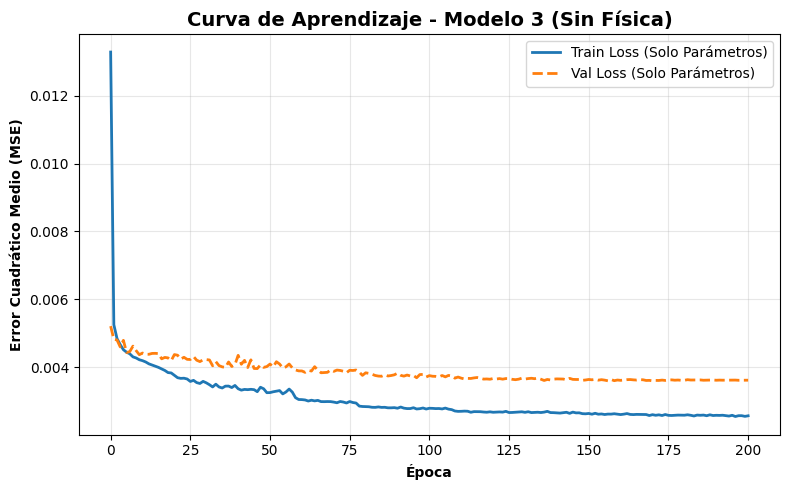

In [9]:
# ====================================================================
# --- CURVA DE APRENDIZAJE: ESTUDIO DE ABLACIÓN (SÓLO PARÁMETROS)
# ====================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Como total y params son lo mismo ahora, dibujamos solo la de params
plt.plot(history['params'], label='Train Loss (Solo Parámetros)', linewidth=2)
plt.plot(history['val_params'], label='Val Loss (Solo Parámetros)', linewidth=2, linestyle='--')

plt.title('Curva de Aprendizaje - Modelo 3 (Sin Física)', fontsize=14, fontweight='bold')
plt.xlabel('Época', fontweight='bold')
plt.ylabel('Error Cuadrático Medio (MSE)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Métricas sobre el conjunto test
Se calculan en **escala real** y **escala normalizada** para poder comparar correctamente.
Se calculan MAE, MSE, RMSE, R2, nMAE, nMSE, MAPE(%) y MaxErr.

In [10]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ====================================================================
# --- 1. INFERENCIA Y RECOPILACIÓN DE DATOS ---
# ====================================================================
model.eval()
all_pred_norm, all_true_norm = [], []
all_pred_spec, all_true_spec = [], []

with torch.no_grad():
    for bX, bYp, bYs in test_loader:
        pred_norm = model(bX)
        pred_spec = build_spectrum(pred_norm, wl_norm_t, cfg.sigma_ev)
        
        all_pred_norm.append(pred_norm.numpy())
        all_true_norm.append(bYp.numpy())
        all_pred_spec.append(pred_spec.numpy())
        all_true_spec.append(bYs.numpy())

pred_norm_np = np.vstack(all_pred_norm)   # (N_te, 6)
true_norm_np = np.vstack(all_true_norm)
pred_spec_np = np.vstack(all_pred_spec)   # (N_te, 100)
true_spec_np = np.vstack(all_true_spec)

# ====================================================================
# --- 2. DESESCALADO A UNIDADES REALES (Se mantiene tu lógica) ---
# ====================================================================
def denorm_params(arr_norm):
    """Devuelve array (N,6) en unidades reales: nm para cols 0,2,4; intensidad para 1,3,5."""
    out = arr_norm.copy()
    for col in [0, 2, 4]:
        out[:, col] = denorm_nm(arr_norm[:, col])
    for col in [1, 3, 5]:
        out[:, col] = denorm_intensity(arr_norm[:, col])
    return out

pred_real = denorm_params(pred_norm_np)
true_real = denorm_params(true_norm_np)

pred_spec_real = denorm_intensity(pred_spec_np)
true_spec_real = denorm_intensity(true_spec_np)

# ====================================================================
# --- 3. MOTOR DE MÉTRICAS AVANZADO (Para el Tutor) ---
# ====================================================================
def get_metrics_df(y_true, y_pred, names):
    """Calcula todas las métricas exigidas y devuelve un DataFrame limpio."""
    metrics = []
    for i in range(y_true.shape[1]):
        t = y_true[:, i]
        p = y_pred[:, i]
        
        mae = mean_absolute_error(t, p)
        mse = mean_squared_error(t, p)
        rmse = np.sqrt(mse)
        r2 = r2_score(t, p)
        
        # nMAE y nMSE (Normalizados por el rango de la variable: max - min)
        rango = t.max() - t.min()
        if rango == 0: rango = 1e-9 # Evitar división por cero
        n_mae = mae / rango
        n_mse = mse / (rango ** 2)
        
        # MAPE (Añadimos epsilon 1e-8 para evitar división por ceros absolutos)
        mape = np.mean(np.abs((t - p) / (np.abs(t) + 1e-8))) * 100 
        
        # Max Error (El peor error de toda la base de datos)
        max_err = np.max(np.abs(t - p))
        
        metrics.append([mae, mse, rmse, r2, n_mae, n_mse, mape, max_err])
        
    df = pd.DataFrame(metrics, columns=['MAE', 'MSE', 'RMSE', 'R2', 'nMAE', 'nMSE', 'MAPE(%)', 'MaxErr'], index=names)
    
    # Añadir fila de Media Global
    df.loc['MEDIA GLOBAL'] = df.mean()
    return df

param_names = ['nm_R1', 'R1', 'nm_Rmax', 'Rmax', 'nm_Rmin', 'Rmin']

print("\n" + "="*90)
print(" 1. MÉTRICAS DE LOS 6 PARÁMETROS (ESCALA NORMALIZADA [-1, 1])")
print("="*90)
df_norm = get_metrics_df(true_norm_np, pred_norm_np, param_names)
display(df_norm.round(4)) # Display crea una tabla bonita en Jupyter

print("\n" + "="*90)
print(" 2. MÉTRICAS DE LOS 6 PARÁMETROS (ESCALA REAL FÍSICA)")
print("="*90)
df_real = get_metrics_df(true_real, pred_real, param_names)
display(df_real.round(4))

# ====================================================================
# --- 4. MÉTRICAS GLOBALES DEL ESPECTRO (100 PUNTOS) ---
# ====================================================================
print("\n" + "="*90)
print(" 3. MÉTRICAS DEL ESPECTRO RECONSTRUIDO (100 PUNTOS)")
print("="*90)
mae_spec_norm = mean_absolute_error(true_spec_np, pred_spec_np)
r2_spec_norm = r2_score(true_spec_np.flatten(), pred_spec_np.flatten())

mae_spec_real = mean_absolute_error(true_spec_real, pred_spec_real)
r2_spec_real = r2_score(true_spec_real.flatten(), pred_spec_real.flatten())

print(f" [NORMALIZADO] MAE: {mae_spec_norm:.4f}  |  R2: {r2_spec_norm:.4f}")
print(f" [ESCALA REAL] MAE: {mae_spec_real:.4f}  |  R2: {r2_spec_real:.4f}")


print(f" Muestras totales en test: {len(pred_real)}")



 1. MÉTRICAS DE LOS 6 PARÁMETROS (ESCALA NORMALIZADA [-1, 1])


,MAE,MSE,RMSE,R2,nMAE,nMSE,MAPE(%),MaxErr
nm_R1,0.0313,0.0056,0.0747,0.5430,0.0221,0.0028,7.8961,1.2460
R1,0.0156,0.0006,0.0253,0.2319,0.0265,0.0019,555.4483,0.3403
nm_Rmax,0.0264,0.0014,0.0380,0.2721,0.0519,0.0056,4.4506,0.3172
Rmax,0.0572,0.0054,0.0737,0.5501,0.0632,0.0066,31.8277,0.4606
nm_Rmin,0.0413,0.0030,0.0550,0.3551,0.0807,0.0115,5.5055,0.2210
Rmin,0.0576,0.0055,0.0739,0.3281,0.0868,0.0124,43.8608,0.4219
MEDIA GLOBAL,0.0383,0.0036,0.0568,0.3800,0.0552,0.0068,108.1648,0.5012



 2. MÉTRICAS DE LOS 6 PARÁMETROS (ESCALA REAL FÍSICA)


,MAE,MSE,RMSE,R2,nMAE,nMSE,MAPE(%),MaxErr
nm_R1,13.1488,982.6483,31.3472,0.5430,0.0221,0.0028,2.8484,523.1548
R1,22.9205,1385.0186,37.2158,0.2319,0.0265,0.0019,555.5851,500.1916
nm_Rmax,11.1023,255.1317,15.9728,0.2721,0.0519,0.0056,3.0546,133.1897
Rmax,84.1465,11754.0771,108.4162,0.5501,0.0632,0.0066,31.8277,677.1341
nm_Rmin,17.3303,532.5986,23.0781,0.3551,0.0807,0.0115,5.8616,92.7905
Rmin,84.7377,11787.6143,108.5708,0.3281,0.0868,0.0124,43.8608,620.2656
MEDIA GLOBAL,38.8977,4449.5148,54.1002,0.3800,0.0552,0.0068,107.1730,424.4544



 3. MÉTRICAS DEL ESPECTRO RECONSTRUIDO (100 PUNTOS)
 [NORMALIZADO] MAE: 0.0267  |  R2: 0.6560
 [ESCALA REAL] MAE: 39.3053  |  R2: 0.6560
 Muestras totales en test: 2633


## 11. Visualización: 4 ejemplos aleatorios del test

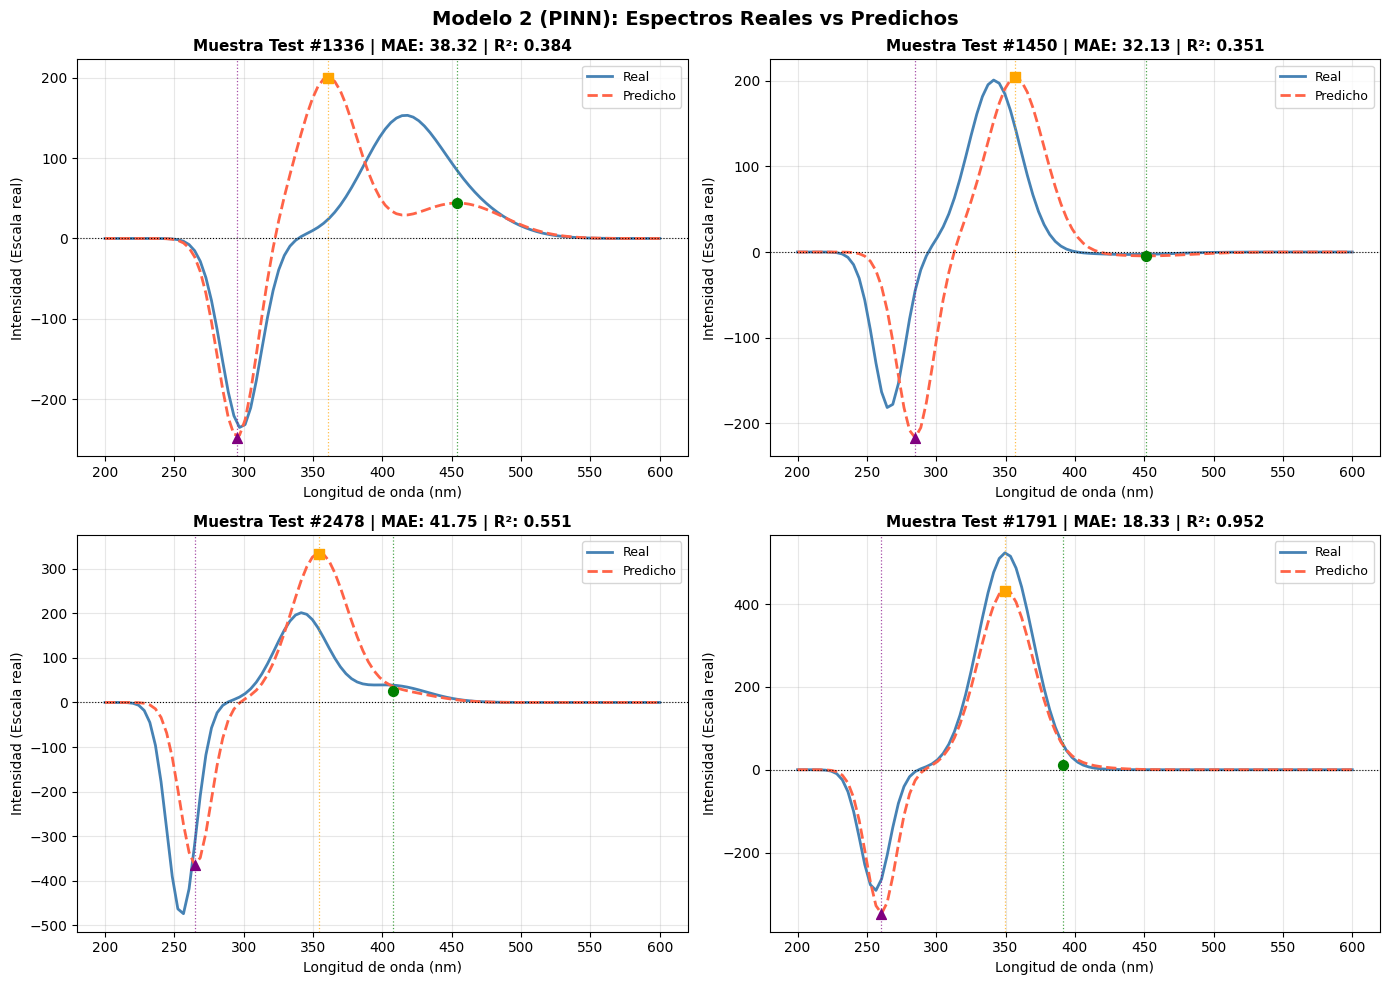

In [11]:
# ====================================================================
# --- VISUALIZAR 4 MUESTRAS (FUSIONADO Y SINCRONIZADO) - MODELO 2 ---
# ====================================================================
# Usamos exactamente la misma semilla y método que en el Modelo 1
np.random.seed(42) 
indices_muestra = np.random.choice(len(pred_spec_real), size=4, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, i in zip(axes, indices_muestra):
    # Espectros en escala real
    ax.plot(wl_nm, true_spec_real[i],  label='Real', linewidth=2, color='steelblue')
    ax.plot(wl_nm, pred_spec_real[i],  label='Predicho', linewidth=2, color='tomato', linestyle='--')

    # Marcar los 3 picos predichos (en nm real)
    for nm_col, r_col, color, marker in [
            (0, 1, 'green',  'o'),
            (2, 3, 'orange', 's'),
            (4, 5, 'purple', '^')]:
        nm_pred = pred_real[i, nm_col]
        r_pred  = pred_real[i, r_col]
        ax.axvline(nm_pred, color=color, linestyle=':', linewidth=0.9, alpha=0.7)
        ax.scatter([nm_pred], [r_pred], color=color, marker=marker, zorder=5, s=50)

    # Calcular métricas locales
    mae_i = mean_absolute_error(true_spec_real[i], pred_spec_real[i])
    r2_i  = r2_score(true_spec_real[i], pred_spec_real[i])
    
    ax.set_title(f'Muestra Test #{i} | MAE: {mae_i:.2f} | R²: {r2_i:.3f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Longitud de onda (nm)')
    ax.set_ylabel('Intensidad (Escala real)')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='dotted')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Modelo 2 (PINN): Espectros Reales vs Predichos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Guardar modelo y parámetros de normalización

In [12]:
torch.save({
    'model_state':  model.state_dict(),
    'config':       cfg,
    'I_SCALE':      I_SCALE,
    'NM_MIN':       NM_MIN,
    'NM_MAX':       NM_MAX,
    'wl_nm':        wl_nm,
    'wl_norm':      wl_norm,
    'target_cols':  target_cols,
}, '6puntos.pt')

print('Modelo guardado en 6puntos.pt')

Modelo guardado en 6puntos.pt
